# Brain Tumor MRI Classification

## Dataset Exploration Notebook

This notebook performs:

- Dataset inspection
- Class distribution analysis
- MRI image visualization
- Image dimension analysis
- Data quality checks

Dataset Classes:

1. Glioma
2. Meningioma
3. Pituitary
4. No Tumor

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

plt.style.use("default")

# Dataset Paths

Define training and testing dataset locations.

In [2]:
BASE_DIR = Path("../datasets/classification")

TRAIN_DIR = BASE_DIR / "Training"
TEST_DIR = BASE_DIR / "Testing"

print("Training Path:", TRAIN_DIR)
print("Testing Path :", TEST_DIR)

Training Path: ..\datasets\classification\Training
Testing Path : ..\datasets\classification\Testing


# Available Classes

In [3]:
classes = sorted(os.listdir(TRAIN_DIR))

print("Classes Found:")
print(classes)

Classes Found:
['glioma', 'meningioma', 'notumor', 'pituitary']


# Count Images Per Class

In [4]:
train_counts = {}

for cls in classes:
    
    class_path = TRAIN_DIR / cls
    
    count = len(os.listdir(class_path))
    
    train_counts[cls] = count

pd.DataFrame(
    train_counts.items(),
    columns=["Class","Images"]
)

,Class,Images
0,glioma,1400
1,meningioma,1400
2,notumor,1400
3,pituitary,1400


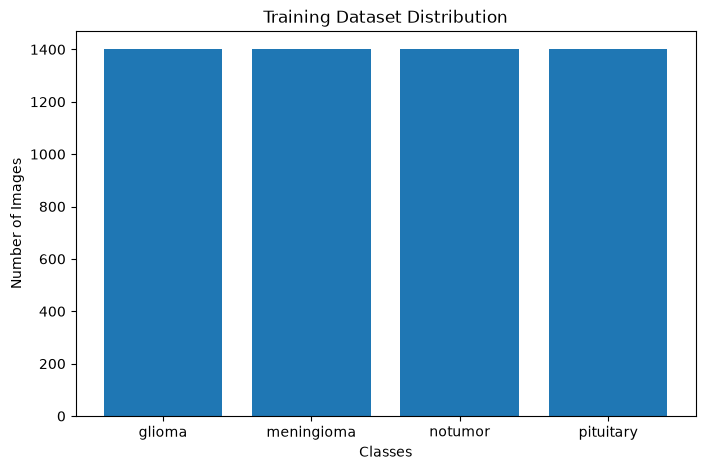

In [5]:
plt.figure(figsize=(8,5))

plt.bar(
    train_counts.keys(),
    train_counts.values()
)

plt.title("Training Dataset Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.show()

# Sample MRI Images

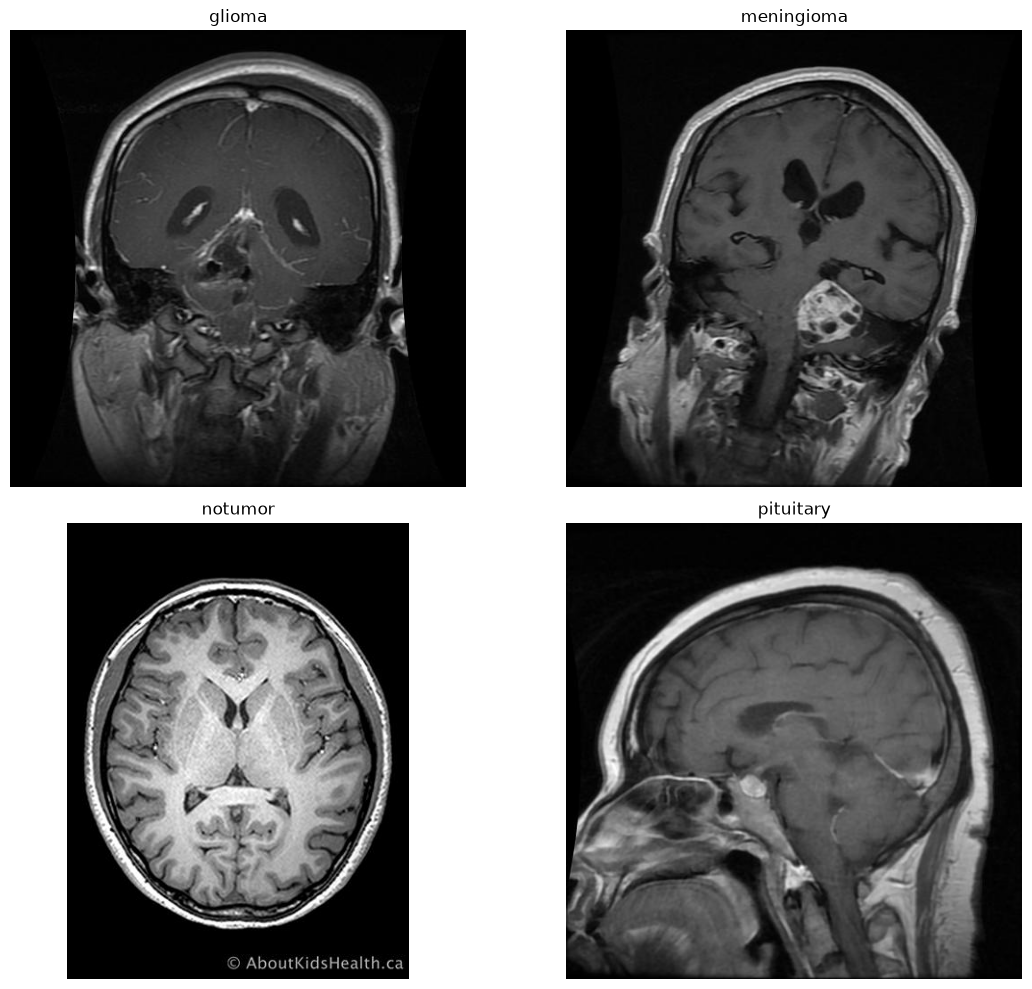

In [6]:
import random

plt.figure(figsize=(12,10))

for i, cls in enumerate(classes):
    
    image_name = random.choice(
        os.listdir(TRAIN_DIR / cls)
    )
    
    image_path = TRAIN_DIR / cls / image_name
    
    image = cv2.imread(str(image_path))
    
    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(2,2,i+1)
    
    plt.imshow(image)
    
    plt.title(cls)
    
    plt.axis("off")

plt.tight_layout()

plt.show()

# Image Dimension Analysis

In [7]:
dimensions = []

for cls in classes:
    
    image_name = os.listdir(
        TRAIN_DIR / cls
    )[0]

    image_path = TRAIN_DIR / cls / image_name

    image = cv2.imread(str(image_path))

    dimensions.append(
        image.shape
    )

dimensions

[(512, 512, 3), (512, 512, 3), (251, 201, 3), (512, 512, 3)]

In [8]:
for cls in classes:
    
    image_name = os.listdir(
        TRAIN_DIR / cls
    )[0]

    image_path = TRAIN_DIR / cls / image_name

    image = cv2.imread(str(image_path))

    print(
        cls,
        "->",
        image.shape
    )

glioma -> (512, 512, 3)
meningioma -> (512, 512, 3)
notumor -> (251, 201, 3)
pituitary -> (512, 512, 3)


# Pixel Statistics

In [9]:
sample_class = classes[0]

sample_image = os.listdir(
    TRAIN_DIR / sample_class
)[0]

sample_path = (
    TRAIN_DIR
    / sample_class
    / sample_image
)

img = cv2.imread(str(sample_path))

img = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

print("Minimum Pixel :", img.min())
print("Maximum Pixel :", img.max())
print("Mean Pixel    :", img.mean())

Minimum Pixel : 0
Maximum Pixel : 255
Mean Pixel    : 34.5438232421875


# Image Normalization Demonstration

Pixel values are converted from:

0 - 255

to

0 - 1

This helps neural networks converge faster.

In [10]:
normalized_img = img / 255.0

print("Minimum :", normalized_img.min())
print("Maximum :", normalized_img.max())

Minimum : 0.0
Maximum : 1.0


# Dataset Exploration Summary

Observations:

- Dataset contains four classes
- MRI images are RGB
- Images have varying dimensions
- Images must be resized before training
- Pixel values require normalization

Next Notebook:

02_data_pipeline.ipynb